In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import scanpy as sc
import pandas as pd
from scvi.nn import FCLayers
import numpy as np
from torch.distributions import NegativeBinomial
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import os

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

/data/sagar/ae-network/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/sagar/ae-network/.venv/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/data/sagar/ae-network/.venv/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


# Data prep

In [2]:
source_adata = sc.read("data/sq_cell_feature_1.h5ad")
target_adata = sc.read("data/sq_cell_feature_2.h5ad")
merged_cells = pd.read_parquet("data/merged_aligned_cells.parquet")

print(f"Source dataset: {source_adata.shape[0]} cells, {source_adata.shape[1]} genes")
print(f"Target dataset: {target_adata.shape[0]} cells, {target_adata.shape[1]} genes")

Source dataset: 245754 cells, 289 genes
Target dataset: 271693 cells, 5001 genes


In [3]:
source_cell_to_idx = {cell: idx for idx, cell in enumerate(source_adata.obs_names)}
target_cell_to_idx = {cell: idx for idx, cell in enumerate(target_adata.obs_names)}

In [4]:
source_cell_to_idx

{'aaaadcac-1': 0,
 'aaaaieak-1': 1,
 'aaaanbhm-1': 2,
 'aaaankfe-1': 3,
 'aaaankfi-1': 4,
 'aaaaoeaa-1': 5,
 'aaabbmdc-1': 6,
 'aaabnbbd-1': 7,
 'aaacicpc-1': 8,
 'aaackknk-1': 9,
 'aaacoijf-1': 10,
 'aaacpgdb-1': 11,
 'aaaddpph-1': 12,
 'aaadlllb-1': 13,
 'aaaehhcn-1': 14,
 'aaafglek-1': 15,
 'aaagbfcp-1': 16,
 'aaagbhin-1': 17,
 'aaagffcj-1': 18,
 'aaaghebd-1': 19,
 'aaagmimh-1': 20,
 'aaagmkhh-1': 21,
 'aaahcpan-1': 22,
 'aaahffcd-1': 23,
 'aaahfijd-1': 24,
 'aaahmeok-1': 25,
 'aaahpahj-1': 26,
 'aaaiaffn-1': 27,
 'aaaiahaf-1': 28,
 'aaaiffem-1': 29,
 'aaaighdb-1': 30,
 'aaainbdl-1': 31,
 'aaaiobkb-1': 32,
 'aaajelnc-1': 33,
 'aaajkggj-1': 34,
 'aaajohcl-1': 35,
 'aaakaiff-1': 36,
 'aaakgmfi-1': 37,
 'aaakhica-1': 38,
 'aaaleabc-1': 39,
 'aaalhfbf-1': 40,
 'aaalhhdf-1': 41,
 'aaalmjbi-1': 42,
 'aaambddm-1': 43,
 'aaamhpgg-1': 44,
 'aaamjdcl-1': 45,
 'aaamkade-1': 46,
 'aaanajgp-1': 47,
 'aaancmjd-1': 48,
 'aaankepo-1': 49,
 'aaanleea-1': 50,
 'aaanmdpc-1': 51,
 'aaanpjhl-1': 52,
 'a

In [5]:
# Find corresponding pairs
correspondence_pairs_idx = []
for _, row in merged_cells.iterrows():
    source_id = row['cell_id_source']
    target_id = row['cell_id_target']
    
    # Only process if both cells exist in their respective datasets
    if source_id in source_cell_to_idx and target_id in target_cell_to_idx:
        source_idx = source_cell_to_idx[source_id]
        target_idx = target_cell_to_idx[target_id]
        correspondence_pairs_idx.append((source_idx, target_idx))

In [6]:
correspondence_pairs_idx

[(0, 55904),
 (0, 55908),
 (2, 55880),
 (3, 1053),
 (3, 55883),
 (4, 55914),
 (4, 55915),
 (5, 1052),
 (5, 1056),
 (6, 55878),
 (7, 55903),
 (7, 55905),
 (7, 55906),
 (7, 55907),
 (7, 55913),
 (8, 55882),
 (8, 55884),
 (9, 55912),
 (11, 1027),
 (11, 55929),
 (13, 1164),
 (13, 1166),
 (15, 55931),
 (15, 55945),
 (16, 1168),
 (16, 55928),
 (16, 55932),
 (18, 1160),
 (19, 1124),
 (23, 1165),
 (25, 1167),
 (28, 55926),
 (29, 1158),
 (30, 1159),
 (30, 55927),
 (31, 1123),
 (32, 55923),
 (32, 55925),
 (33, 55930),
 (34, 55924),
 (34, 55933),
 (35, 55962),
 (36, 1028),
 (36, 55966),
 (38, 1055),
 (40, 1021),
 (41, 1019),
 (42, 1054),
 (42, 55885),
 (44, 1020),
 (45, 1032),
 (45, 55920),
 (46, 1030),
 (46, 55921),
 (47, 55974),
 (48, 55918),
 (48, 55975),
 (49, 55917),
 (49, 55973),
 (50, 55967),
 (51, 55919),
 (52, 1040),
 (52, 1045),
 (53, 1044),
 (53, 1046),
 (53, 55637),
 (55, 1034),
 (56, 55628),
 (57, 55898),
 (58, 55889),
 (58, 55897),
 (58, 55900),
 (59, 1047),
 (59, 55886),
 (59, 5588

In [7]:

print(f"Found {len(correspondence_pairs_idx)} corresponding cell pairs")

Found 244437 corresponding cell pairs


In [8]:
# ---------- Paired Dataset ----------
class PairedDataset(Dataset):
    def __init__(self, source_adata, target_adata, pairs):
        self.source_X = source_adata.X
        self.target_X = target_adata.X
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        source_idx, target_idx = self.pairs[idx]
        source_data = self.source_X[source_idx].toarray().squeeze()
        target_data = self.target_X[target_idx].toarray().squeeze()
        return torch.tensor(source_data, dtype=torch.float32), torch.tensor(target_data, dtype=torch.float32)

In [9]:
paired_dataset = PairedDataset(source_adata, target_adata, correspondence_pairs_idx)
dataloader = DataLoader(paired_dataset, batch_size=512, shuffle=True, num_workers=4)

# Model 

In [10]:
class SpatialAutoencoder(nn.Module):
    def __init__(self, n_genes_source, n_genes_target, latent_dim=32, hidden_dims=[128, 64]):
        super().__init__()
        
        # Source encoder
        self.encoder_source = nn.Sequential(
            FCLayers(
                n_in=n_genes_source,
                n_out=latent_dim,
                n_hidden=hidden_dims,
                dropout_rate=0.1,
                use_batch_norm=True
            )
        )
        
        # Target encoder
        self.encoder_target = nn.Sequential(
            FCLayers(
                n_in=n_genes_target,
                n_out=latent_dim,
                n_hidden=hidden_dims,
                dropout_rate=0.1,
                use_batch_norm=True
            )
        )
        
        # Decoder for target data
        self.decoder_hidden = FCLayers(
            n_in=latent_dim,
            n_out=hidden_dims[0],
            n_hidden=hidden_dims[::-1],
            dropout_rate=0.1
        )
        
        # Output heads
        self.decoder_mean = nn.Linear(hidden_dims[0], n_genes_target)
        self.decoder_dispersion = nn.Linear(hidden_dims[0], n_genes_target)

    def forward(self, x_source, x_target):
        # Encode
        z_source = self.encoder_source(x_source)
        z_target = self.encoder_target(x_target)
        
        # Decode using source latent
        hidden = self.decoder_hidden(z_source)
        mean_logits = self.decoder_mean(hidden)
        dispersion_logits = self.decoder_dispersion(hidden)
        
        # Transform parameters
        mean = torch.exp(mean_logits)
        dispersion = torch.exp(dispersion_logits)
        
        return z_source, z_target, mean, dispersion

# Losses

In [11]:
def compute_mmd(x, y, sigmas=None):
    if sigmas is None:
        sigmas = [0.01, 0.1, 1, 10, 100]
    
    xx, yy, xy = 0, 0, 0
    for sigma in sigmas:
        gamma = 1.0 / (2 * sigma**2)
        
        # Compute kernels
        x_sq = torch.sum(x**2, dim=1, keepdim=True)
        y_sq = torch.sum(y**2, dim=1, keepdim=True)
        
        x_dot_x = -2 * torch.matmul(x, x.t()) + x_sq + x_sq.t()
        y_dot_y = -2 * torch.matmul(y, y.t()) + y_sq + y_sq.t()
        x_dot_y = -2 * torch.matmul(x, y.t()) + x_sq + y_sq.t()
        
        xx += torch.mean(torch.exp(-gamma * x_dot_x))
        yy += torch.mean(torch.exp(-gamma * y_dot_y))
        xy += torch.mean(torch.exp(-gamma * x_dot_y))
        
    return xx + yy - 2 * xy

In [12]:
def negative_binomial_loss(x, mu, theta, eps=1e-8):
    """Negative binomial loss that works with continuous values.
    Based on scVI implementation that allows for continuous approximations.
    """
    x = torch.clamp(x, min=0)  # Ensure no negative values
    mu = torch.clamp(mu, min=eps)
    theta = torch.clamp(theta, min=eps)
    
    log_theta_mu_eps = torch.log(theta + mu + eps)
    res = (
        theta * (torch.log(theta + eps) - log_theta_mu_eps)
        + x * (torch.log(mu + eps) - log_theta_mu_eps)
        + torch.lgamma(x + theta)
        - torch.lgamma(theta)
        - torch.lgamma(x + 1)
    )
    
    res = -torch.mean(torch.sum(res, dim=1))
    return res

# training and plotting

In [13]:
def train(model, dataloader, num_epochs=20, lr=1e-3, lambda_mmd=1.0, lambda_elbo=1.0, 
          patience=5, device='cuda' if torch.cuda.is_available() else 'cpu'):
    
    print(f"Training on: {device}")
    
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    model.train()
    
    all_losses = []
    all_mmd_losses = []
    all_elbo_losses = []
    
    best_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(num_epochs):
        total_loss = 0.0
        total_mmd_loss = 0.0
        total_elbo_loss = 0.0
        
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for x_source, x_target in pbar:
            x_source = x_source.to(device)
            x_target = x_target.to(device)
            
            z_source, z_target, mean, dispersion = model(x_source, x_target)
            
            mmd_loss = compute_mmd(z_source, z_target)
            elbo_loss = negative_binomial_loss(x_target, mean, dispersion)
            
            loss = lambda_mmd * mmd_loss + lambda_elbo * elbo_loss
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
            optimizer.step()
            
            # Update progress bar
            total_loss += loss.item()
            total_mmd_loss += mmd_loss.item()
            total_elbo_loss += elbo_loss.item()
            
            pbar.set_postfix({
                'loss': total_loss / (pbar.n + 1), 
                'mmd': total_mmd_loss / (pbar.n + 1), 
                'elbo': total_elbo_loss / (pbar.n + 1)
            })
        
        avg_loss = total_loss / len(dataloader)
        all_losses.append(avg_loss)
        all_mmd_losses.append(total_mmd_loss / len(dataloader))
        all_elbo_losses.append(total_elbo_loss / len(dataloader))
        
        # Learning rate scheduling
        scheduler.step(avg_loss)
        
        # Early stopping
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), 'best_spatial_autoencoder.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping after {epoch+1} epochs")
                break
    
    # Load best model
    model.load_state_dict(torch.load('best_spatial_autoencoder.pt'))
    return model, all_losses, all_mmd_losses, all_elbo_losses

In [14]:
def plot_loss_curves(losses, mmd_losses, elbo_losses):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.plot(losses)
    plt.title('Total Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    plt.subplot(1, 3, 2)
    plt.plot(mmd_losses)
    plt.title('MMD Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    plt.subplot(1, 3, 3)
    plt.plot(elbo_losses)
    plt.title('ELBO Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    plt.tight_layout()
    plt.savefig('training_loss_curves.png')
    plt.show()

In [15]:
def extract_latents_batched(model, source_adata, target_adata, paired_indices, batch_size=1024, 
                           device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    model = model.to(device)
    
    # Create dataset and dataloader for batching
    paired_dataset = PairedDataset(source_adata, target_adata, paired_indices)
    dataloader = DataLoader(paired_dataset, batch_size=batch_size, shuffle=False)
    
    source_latents = []
    target_latents = []
    
    with torch.no_grad():
        for x_source_batch, x_target_batch in tqdm(dataloader, desc="Extracting latent embeddings"):
            x_source_batch = x_source_batch.to(device)
            x_target_batch = x_target_batch.to(device)
            
            z_source_batch, z_target_batch, _, _ = model(x_source_batch, x_target_batch)
            
            source_latents.append(z_source_batch.cpu().numpy())
            target_latents.append(z_target_batch.cpu().numpy())
    
    # Concatenate batches
    source_latents = np.vstack(source_latents)
    target_latents = np.vstack(target_latents)
    
    # Stack all latents and create labels
    combined_latents = np.vstack([source_latents, target_latents])
    cell_labels = ['source'] * len(source_latents) + ['target'] * len(target_latents)
    
    return source_latents, target_latents, combined_latents, cell_labels

In [16]:
def visualize_latent_space(source_latents, target_latents, combined_latents, cell_labels, 
                           leiden_resolution=0.5, umap_n_neighbors=15, sample_size=None):
    # Optionally downsample for faster visualization
    if sample_size is not None and len(combined_latents) > sample_size:
        idx = np.random.choice(len(combined_latents), sample_size, replace=False)
        combined_latents_subset = combined_latents[idx]
        cell_labels_subset = [cell_labels[i] for i in idx]
    else:
        combined_latents_subset = combined_latents
        cell_labels_subset = cell_labels
    
    # Create AnnData object
    latent_adata = sc.AnnData(combined_latents_subset)
    latent_adata.obs["modality"] = cell_labels_subset
    
    # Add source/target index for coloring later
    source_indices = np.arange(len(source_latents))
    target_indices = np.arange(len(target_latents))
    
    if sample_size is not None:
        # Map sampled cells back to original indices
        source_mask = np.array([l == 'source' for l in cell_labels_subset])
        target_mask = np.array([l == 'target' for l in cell_labels_subset])
        latent_adata.obs["original_idx"] = -1
        if np.sum(source_mask) > 0:
            source_sampled = idx[source_mask]
            latent_adata.obs.loc[source_mask, "original_idx"] = source_sampled
        if np.sum(target_mask) > 0:
            target_sampled = idx[target_mask] - len(source_latents)
            latent_adata.obs.loc[target_mask, "original_idx"] = target_sampled
    
    # Compute neighbors and UMAP
    print("Computing neighbors...")
    sc.pp.neighbors(latent_adata, use_rep="X", n_neighbors=umap_n_neighbors, metric='euclidean')
    
    print("Computing UMAP...")
    sc.tl.umap(latent_adata, min_dist=0.1, spread=1.0)
    
    print("Computing Leiden clusters...")
    sc.tl.leiden(latent_adata, resolution=leiden_resolution)
    
    # Create figure with plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot UMAP by modality
    sc.pl.umap(latent_adata, color="modality", ax=axes[0], show=False, 
               title="UMAP of Shared Latent Space (Source vs Target)")
    
    # Plot UMAP by leiden clusters
    sc.pl.umap(latent_adata, color="leiden", ax=axes[1], show=False,
               title="UMAP of Shared Latent Space (Clusters)")
    
    plt.tight_layout()
    plt.savefig('latent_space_visualization.png', dpi=300)
    plt.show()
    
    return latent_adata

# main training and plotting

In [19]:
model = SpatialAutoencoder(
        n_genes_source=source_adata.n_vars,
        n_genes_target=target_adata.n_vars,
        latent_dim=32,
        hidden_dims=[256, 128]
    )

In [24]:
print("Training model...\n")
trained_model, losses, mmd_losses, elbo_losses = train(
    model=model,
    dataloader=dataloader,
    num_epochs=100,
    lr=5e-4,
    lambda_mmd=0.5,
    lambda_elbo=1.0,
    patience=10
)

Training model...

Training on: cuda


Epoch 56/100: 100%|██████████| 478/478 [00:20<00:00, 23.81it/s, loss=538, mmd=0.0107, elbo=538]      


Early stopping after 56 epochs


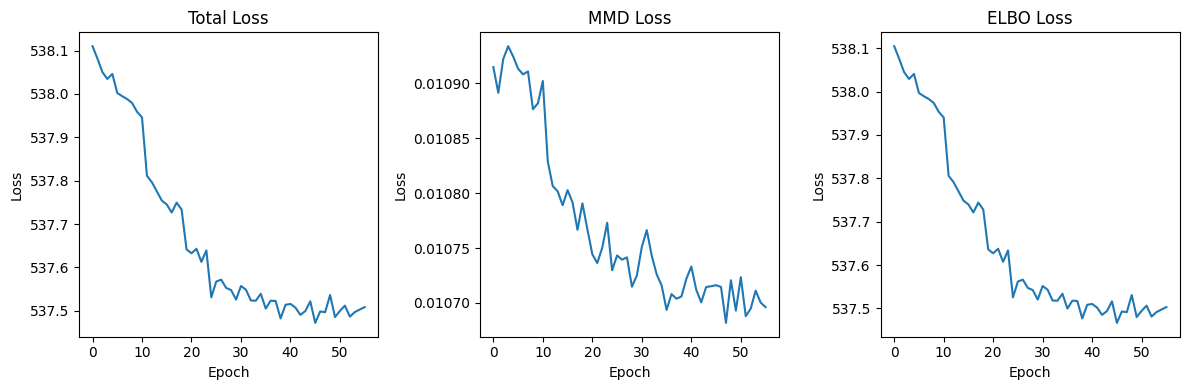

In [25]:
plot_loss_curves(losses, mmd_losses, elbo_losses)

In [26]:
# Extract latent representations for visualization
print("Extracting latent representations...")
source_latents, target_latents, combined_latents, cell_labels = extract_latents_batched(
    trained_model, 
    source_adata, 
    target_adata, 
    correspondence_pairs_idx
)



Extracting latent representations...


Extracting latent embeddings: 100%|██████████| 239/239 [00:55<00:00,  4.33it/s]


Visualizing latent space with 100000 sampled cells...
Computing neighbors...
Computing UMAP...
Computing Leiden clusters...


/tmp/ipykernel_1169532/1514400518.py:40: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(latent_adata, resolution=leiden_resolution)


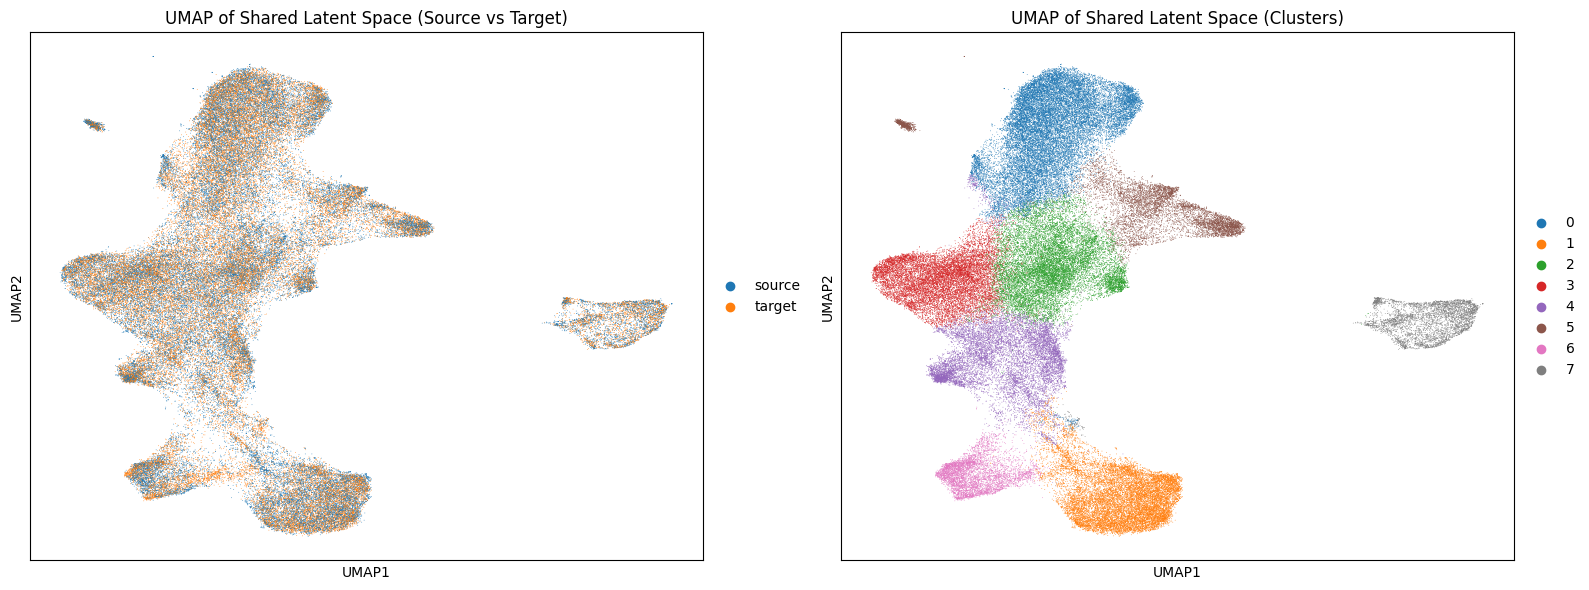

In [27]:
# Visualize latent space (sample for speed if needed)
sample_size = min(100000, len(combined_latents)) 
# sample_size = len(combined_latents)
print(f"Visualizing latent space with {sample_size} sampled cells...")
latent_adata = visualize_latent_space(
    source_latents, 
    target_latents, 
    combined_latents, 
    cell_labels,
    sample_size=sample_size
)

In [30]:
model.load_state_dict(torch.load('best_spatial_autoencoder.pt'))

<All keys matched successfully>

In [31]:
model.eval

<bound method Module.eval of SpatialAutoencoder(
  (encoder_source): Sequential(
    (0): FCLayers(
      (fc_layers): Sequential(
        (Layer 0): Sequential(
          (0): Linear(in_features=289, out_features=32, bias=True)
          (1): BatchNorm1d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): None
          (3): ReLU()
          (4): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (encoder_target): Sequential(
    (0): FCLayers(
      (fc_layers): Sequential(
        (Layer 0): Sequential(
          (0): Linear(in_features=5001, out_features=32, bias=True)
          (1): BatchNorm1d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): None
          (3): ReLU()
          (4): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (decoder_hidden): FCLayers(
    (fc_layers): Sequential(
      (Layer 0): Sequential(
        (0): Linear(in_features=32, out_features=256, bias=True)
        (1): Ba

In [29]:
with torch.no_grad():
    all_z_source, all_z_target = [], []

    for x_source, x_target in dataloader:
        z_source, z_target, _, _ = model(x_source, x_target)
        all_z_source.append(z_source)
        all_z_target.append(z_target)

    all_z_source = torch.cat(all_z_source).cpu().numpy()
    all_z_target = torch.cat(all_z_target).cpu().numpy()
    all_z = np.concatenate([all_z_source, all_z_target], axis=0)


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

In [28]:
n_per_domain = 40000

source_mask = latent_adata.obs["domain"] == "source"
target_mask = latent_adata.obs["domain"] == "target"

source_indices = np.random.choice(
    latent_adata.obs[source_mask].index,
    size=min(n_per_domain, source_mask.sum()),
    replace=False
)

target_indices = np.random.choice(
    latent_adata.obs[target_mask].index,
    size=min(n_per_domain, target_mask.sum()),
    replace=False
)

combined_indices = np.concatenate([source_indices, target_indices])
latent_domain_subset = latent_adata[combined_indices].copy()

KeyError: 'domain'

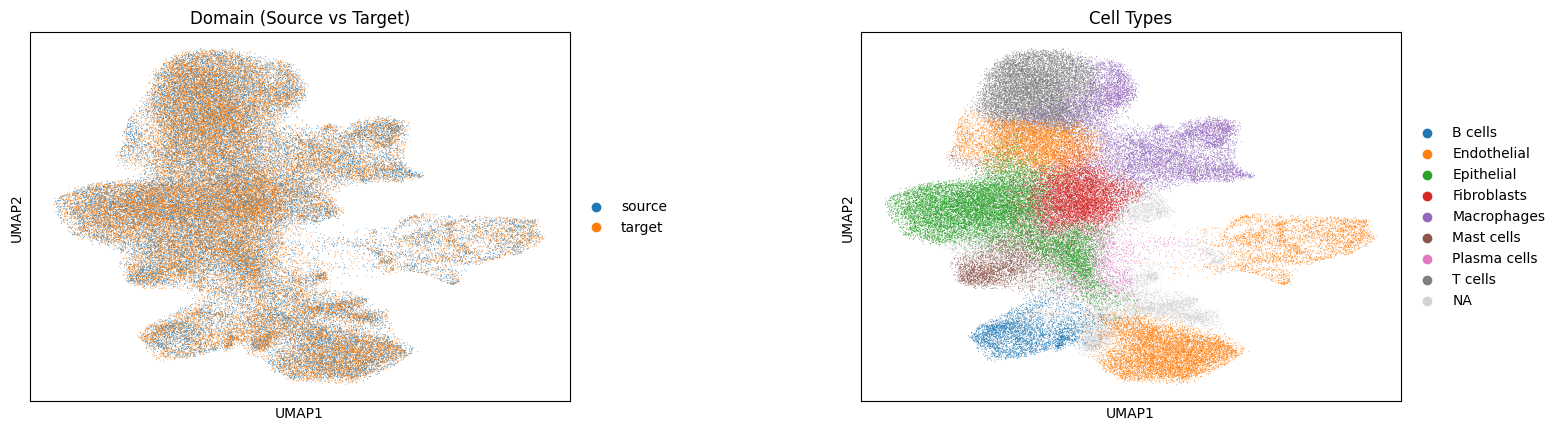

In [37]:
sc.pp.neighbors(latent_domain_subset, use_rep="X")
sc.tl.umap(latent_domain_subset)
sc.tl.leiden(latent_domain_subset)

# Map cell types if needed
latent_domain_subset.obs["cell_type"] = latent_domain_subset.obs["leiden"].map(combined_annotations)

# Plot domain-wise UMAP
sc.pl.umap(latent_domain_subset, color=["domain", "cell_type"], wspace=0.4,
           title=["Domain (Source vs Target)", "Cell Types"])

In [43]:
# 1. Get shared genes
common_genes = source_adata.var_names.intersection(target_adata.var_names)

# 2. Subset both to shared genes
source_common = source_adata[:, common_genes]
target_common = target_adata[:, common_genes]

In [44]:
# Make sure indices are strings (since AnnData uses string obs_names)
source_indices = source_indices.astype(str)
target_indices = target_indices.astype(str)


In [50]:
latent_domain_subset.var_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31'],
      dtype='object')

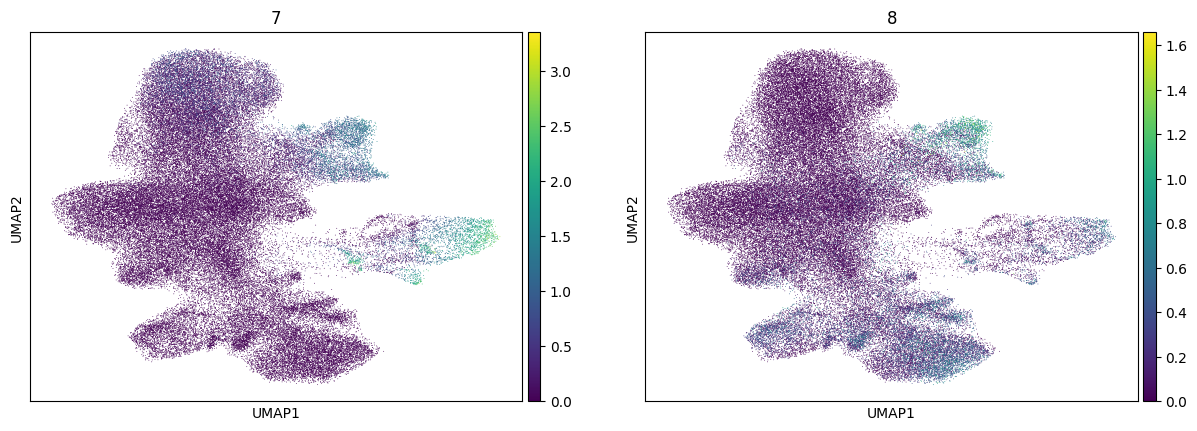

In [53]:
# Plot gene expression on UMAP
sc.pl.umap(latent_domain_subset, color=["7", "8"])